# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Hafiz Ramadhan
- **Email:** cdcc284d6y2766@student.devacademy.id
- **ID Dicoding:** CDCC284D6Y2766


## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana pola perubahan konsentrasi PM2.5 berdasarkan waktu pengamatan?
- **Pertanyaan 2:** Stasiun mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi dan terendah?


## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import gdown
from IPython.display import display

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## Data Wrangling

### Gathering Data

In [3]:


file_id = "1RhU3gJlkteaAQfyn9XOVAz7a5o1-etgr"
output = "air_quality.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1RhU3gJlkteaAQfyn9XOVAz7a5o1-etgr
To: /content/air_quality.zip
100%|██████████| 7.96M/7.96M [00:00<00:00, 219MB/s]


'air_quality.zip'

In [4]:


with zipfile.ZipFile("air_quality.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [5]:

os.listdir("data")

['PRSA_Data_20130301-20170228']

In [6]:
folder_path = "data/PRSA_Data_20130301-20170228"

In [7]:


df_list = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)

        station = file.split("_")[2]
        df["station"] = station

        df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [8]:
df["station"].value_counts()

,count
station,
Changping,35064
Nongzhanguan,35064
Gucheng,35064
Tiantan,35064
Dingling,35064
Dongsi,35064
Aotizhongxin,35064
Wanliu,35064
Wanshouxigong,35064


In [9]:
df.shape
df["station"].nunique()

12

**Insight:**
Pada tahap gathering data, seluruh file CSV berhasil digabungkan ke dalam satu dataframe. Hasil validasi menunjukkan bahwa dataset terdiri dari 12 stasiun unik, yang berarti seluruh data dari masing-masing stasiun berhasil dimuat dengan baik. Selain itu, setiap stasiun memiliki jumlah observasi yang sama, yaitu 35.064 baris, sehingga total data gabungan mencapai 420.768 baris. Hal ini menunjukkan bahwa dataset memiliki cakupan yang konsisten dan siap untuk dianalisis lebih lanjut.



### Assessing Data

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [11]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [14]:
df["station"].unique()
df["wd"].unique()

array(['E', 'ENE', 'NNE', 'N', 'NNW', 'NW', 'NE', 'SW', 'SSW', 'WSW',
       'ESE', 'SE', 'S', 'WNW', 'SSE', 'W', nan], dtype=object)

**Insight:**
Berdasarkan hasil tahap assessing data, dataset Air Quality hasil penggabungan memiliki 420.768 baris dan 18 kolom, sehingga cukup besar dan representatif untuk analisis kualitas udara. Struktur data menunjukkan bahwa sebagian besar kolom numerik sudah memiliki tipe data yang sesuai, yaitu int64 dan float64. Sementara itu, kolom wd dan station bertipe object karena merepresentasikan data kategorikal, yaitu arah angin dan nama stasiun pengamatan.

Dari pemeriksaan missing values, ditemukan bahwa beberapa kolom polutan masih memiliki nilai kosong dalam jumlah yang cukup besar. Missing values paling banyak terdapat pada kolom CO (20.701), O3 (13.277), NO2 (12.116), SO2 (9.021), PM2.5 (8.739), dan PM10 (6.449). Selain itu, beberapa variabel cuaca juga memiliki missing values, meskipun jumlahnya relatif lebih kecil, seperti TEMP (398), PRES (393), DEWP (403), RAIN (390), wd (1.822), dan WSPM (318). Hal ini menunjukkan bahwa proses pembersihan data perlu difokuskan pada penanganan missing values sebelum analisis lebih lanjut dilakukan.

Hasil pengecekan data duplikat menunjukkan nilai 0, yang berarti tidak terdapat baris data yang terduplikasi. Dengan demikian, tidak diperlukan proses penghapusan data ganda pada tahap cleaning data.

Berdasarkan statistik deskriptif, terlihat bahwa beberapa variabel polutan memiliki variasi data yang cukup besar. Sebagai contoh, rata-rata PM2.5 sebesar 79,79 dengan nilai maksimum mencapai 999, sedangkan rata-rata PM10 sebesar 104,60 dengan nilai maksimum juga mencapai 999. Nilai maksimum yang jauh lebih besar dibanding median mengindikasikan adanya nilai ekstrem atau lonjakan polusi pada waktu tertentu. Hal serupa juga terlihat pada variabel CO, yang memiliki rata-rata 1230,77 dengan nilai maksimum 10.000, menunjukkan adanya rentang nilai yang sangat lebar.

Pada variabel cuaca, TEMP memiliki rata-rata 13,54°C dengan rentang dari -19,9°C hingga 41,6°C, yang menunjukkan bahwa data mencakup berbagai kondisi musim dan cuaca. Variabel lain seperti PRES, DEWP, RAIN, dan WSPM juga menunjukkan variasi nilai yang cukup beragam, sehingga bisa menjadi faktor pendukung dalam analisis kualitas udara.

Selain itu, hasil pengecekan nilai unik pada kolom wd menunjukkan bahwa kolom ini berisi berbagai kategori arah angin, seperti NW, WNW, W, E, ENE, NE, ESE, SSE, NNE, SW, SSW, S, SE, NNW, N, dan WSW. Namun, pada kolom ini juga ditemukan nilai NaN, yang menegaskan bahwa kolom kategorikal pun memerlukan penanganan missing values.

Secara keseluruhan, tahap assessing data menunjukkan bahwa dataset sudah memiliki struktur yang cukup baik dan tidak mengandung duplikasi, tetapi masih terdapat missing values serta indikasi nilai ekstrem pada beberapa variabel polutan. Oleh karena itu, tahap cleaning data selanjutnya akan difokuskan pada penanganan missing values, penyiapan format data, dan pembuatan kolom waktu agar dataset lebih siap untuk dianalisis

### Cleaning Data

In [15]:
# salin dataset agar data asli tetap aman
df_clean = df.copy()

# urutkan data berdasarkan station dan waktu
df_clean = df_clean.sort_values(by=["station", "year", "month", "day", "hour"])

# buat kolom datetime
df_clean["datetime"] = pd.to_datetime(df_clean[["year", "month", "day", "hour"]])

# isi missing values per station
df_clean = df_clean.groupby("station", group_keys=False).apply(lambda x: x.ffill().bfill())

# cek hasil cleaning
df_clean.isnull().sum()

/tmp/ipykernel_7204/3606918468.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby("station", group_keys=False).apply(lambda x: x.ffill().bfill())


,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


In [16]:
df_clean.head()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420768 entries, 210384 to 315575
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     420768 non-null  float64       
 6   PM10      420768 non-null  float64       
 7   SO2       420768 non-null  float64       
 8   NO2       420768 non-null  float64       
 9   CO        420768 non-null  float64       
 10  O3        420768 non-null  float64       
 11  TEMP      420768 non-null  float64       
 12  PRES      420768 non-null  float64       
 13  DEWP      420768 non-null  float64       
 14  RAIN      420768 non-null  float64       
 15  wd        420768 non-null  object        
 16  WSPM      420768 non-null  float64    

In [17]:
df_clean = df_clean.reset_index(drop=True)

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     420768 non-null  float64       
 6   PM10      420768 non-null  float64       
 7   SO2       420768 non-null  float64       
 8   NO2       420768 non-null  float64       
 9   CO        420768 non-null  float64       
 10  O3        420768 non-null  float64       
 11  TEMP      420768 non-null  float64       
 12  PRES      420768 non-null  float64       
 13  DEWP      420768 non-null  float64       
 14  RAIN      420768 non-null  float64       
 15  wd        420768 non-null  object        
 16  WSPM      420768 non-null  float64    

**Insight:**
Pada tahap cleaning data, missing values berhasil ditangani sehingga seluruh kolom tidak lagi memiliki nilai kosong. Data juga telah diurutkan berdasarkan stasiun dan waktu pengamatan, kemudian ditambahkan kolom datetime untuk mempermudah analisis berbasis waktu. Setelah index di-reset, struktur dataset menjadi lebih rapi dengan total 420.768 baris dan 19 kolom. Secara keseluruhan, dataset sudah bersih dan siap digunakan pada tahap exploratory data analysis

## Exploratory Data Analysis (EDA)

### Explore ...

In [19]:
# Rata-rata PM2.5 berdasarkan bulan
pm25_by_month = df_clean.groupby("month")["PM2.5"].mean().sort_index()

# Rata-rata PM2.5 berdasarkan jam
pm25_by_hour = df_clean.groupby("hour")["PM2.5"].mean().sort_index()

# Rata-rata PM2.5 berdasarkan stasiun
pm25_by_station = df_clean.groupby("station")["PM2.5"].mean().sort_values(ascending=False)

print("Rata-rata PM2.5 per Bulan")
display(pm25_by_month)

print("Rata-rata PM2.5 per Jam")
display(pm25_by_hour)

print("Rata-rata PM2.5 per Stasiun")
display(pm25_by_station)

Rata-rata PM2.5 per Bulan


,PM2.5
month,
1,94.021657
2,89.164457
3,94.760201
4,73.854074
5,64.194461
6,68.960854
7,71.974628
8,53.648863
9,61.401175


Rata-rata PM2.5 per Jam


,PM2.5
hour,
0,87.962320
1,87.099013
2,85.094872
3,82.554033
4,79.817870
5,76.878548
6,74.651780
7,73.809263
8,74.821030


Rata-rata PM2.5 per Stasiun


,PM2.5
station,
Dongsi,86.310293
Wanshouxigong,85.356562
Nongzhanguan,85.289471
Gucheng,84.345203
Wanliu,83.516054
Aotizhongxin,83.163652
Guanyuan,83.047023
Tiantan,82.255892
Shunyi,80.021067


In [20]:
print("3 stasiun dengan rata-rata PM2.5 tertinggi")
display(pm25_by_station.head(3))

print("3 stasiun dengan rata-rata PM2.5 terendah")
display(pm25_by_station.tail(3))

3 stasiun dengan rata-rata PM2.5 tertinggi


,PM2.5
station,
Dongsi,86.310293
Wanshouxigong,85.356562
Nongzhanguan,85.289471


3 stasiun dengan rata-rata PM2.5 terendah


,PM2.5
station,
Changping,71.119444
Huairou,69.949581
Dingling,67.429857


**Insight:**
- Rata-rata PM2.5 berubah menurut bulan dan jam, sehingga ada indikasi pola musiman dan pola harian pada kualitas udara.
- Terdapat perbedaan rata-rata PM2.5 antar stasiun, yang menunjukkan bahwa tingkat polusi tidak merata di seluruh lokasi pengamatan.


## Visualization & Explanatory Analysis

### Pertanyaan 1:Bagaimana pola perubahan konsentrasi PM2.5 berdasarkan waktu pengamatan?

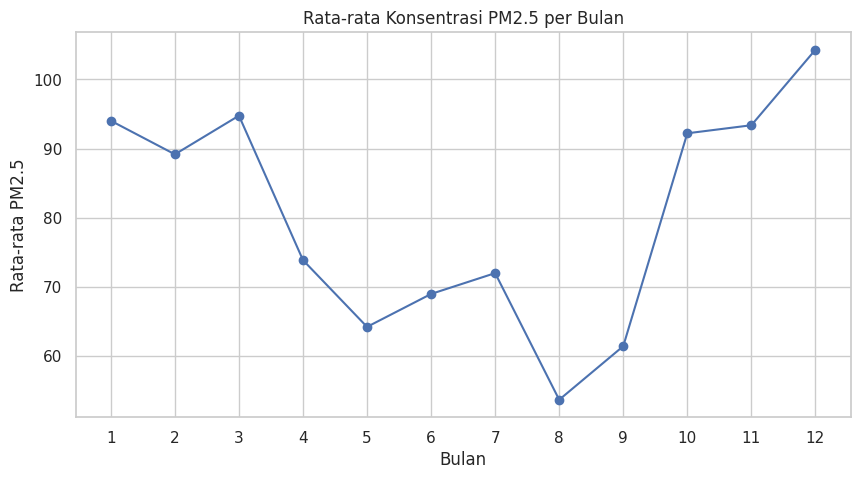

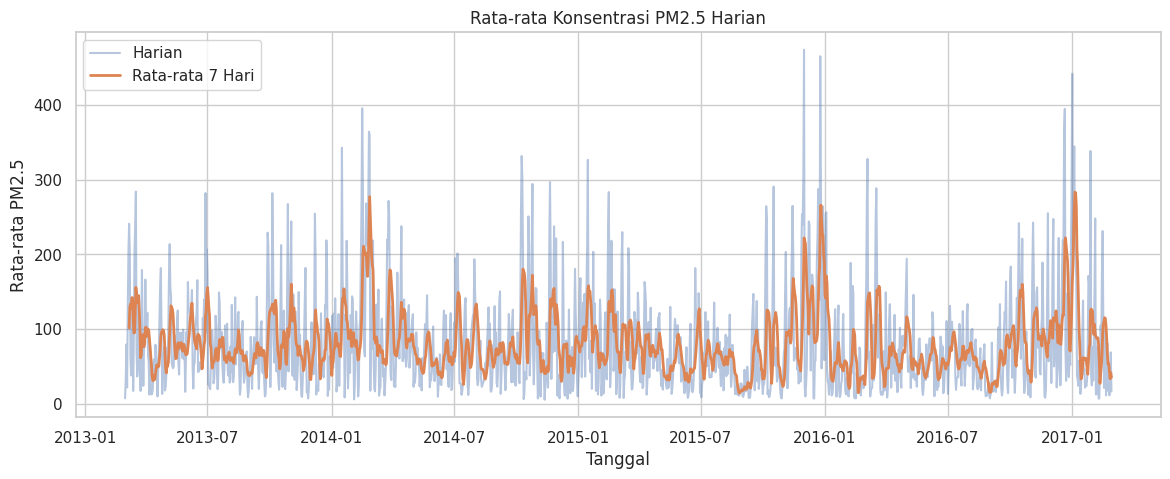

In [21]:
# Agregasi rata-rata PM2.5 per bulan
pm25_by_month = df_clean.groupby("month")["PM2.5"].mean().sort_index()

plt.figure(figsize=(10,5))
plt.plot(pm25_by_month.index, pm25_by_month.values, marker="o")
plt.title("Rata-rata Konsentrasi PM2.5 per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata PM2.5")
plt.xticks(pm25_by_month.index)
plt.show()

daily_pm25 = df_clean.set_index("datetime").groupby("station")["PM2.5"].resample("D").mean().reset_index()
daily_pm25_avg = daily_pm25.groupby("datetime")["PM2.5"].mean()

rolling_pm25 = daily_pm25_avg.rolling(window=7).mean()

plt.figure(figsize=(14,5))
plt.plot(daily_pm25_avg.index, daily_pm25_avg.values, alpha=0.4, label="Harian")
plt.plot(rolling_pm25.index, rolling_pm25.values, linewidth=2, label="Rata-rata 7 Hari")
plt.title("Rata-rata Konsentrasi PM2.5 Harian")
plt.xlabel("Tanggal")
plt.ylabel("Rata-rata PM2.5")
plt.legend()
plt.show()

### Pertanyaan 2: Stasiun mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi dan terendah?


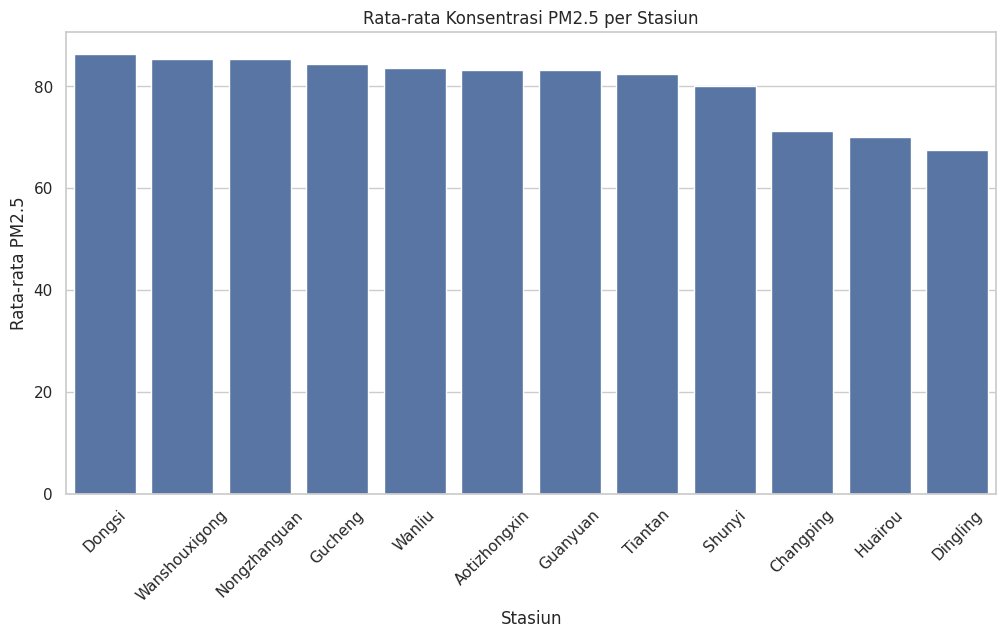

In [22]:
pm25_by_station = df_clean.groupby("station")["PM2.5"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=pm25_by_station.index, y=pm25_by_station.values)
plt.title("Rata-rata Konsentrasi PM2.5 per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("Rata-rata PM2.5")
plt.xticks(rotation=45)
plt.show()


**Insight:**
- Terdapat perbedaan yang jelas pada rata-rata PM2.5 antar stasiun.
- Beberapa stasiun menunjukkan tingkat polusi yang lebih tinggi secara konsisten, sedangkan stasiun lain relatif lebih rendah.


## Analisis Lanjutan (Opsional)

In [23]:
print("Korelasi PM2.5 dengan variabel lain:")
correlation_matrix = df_clean[["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]].corr()
display(correlation_matrix["PM2.5"].sort_values(ascending=False))

Korelasi PM2.5 dengan variabel lain:


,PM2.5
PM2.5,1.000000
PM10,0.876213
CO,0.773015
NO2,0.654310
SO2,0.469207
DEWP,0.112820
PRES,0.019145
RAIN,-0.014153
TEMP,-0.130454
O3,-0.144707


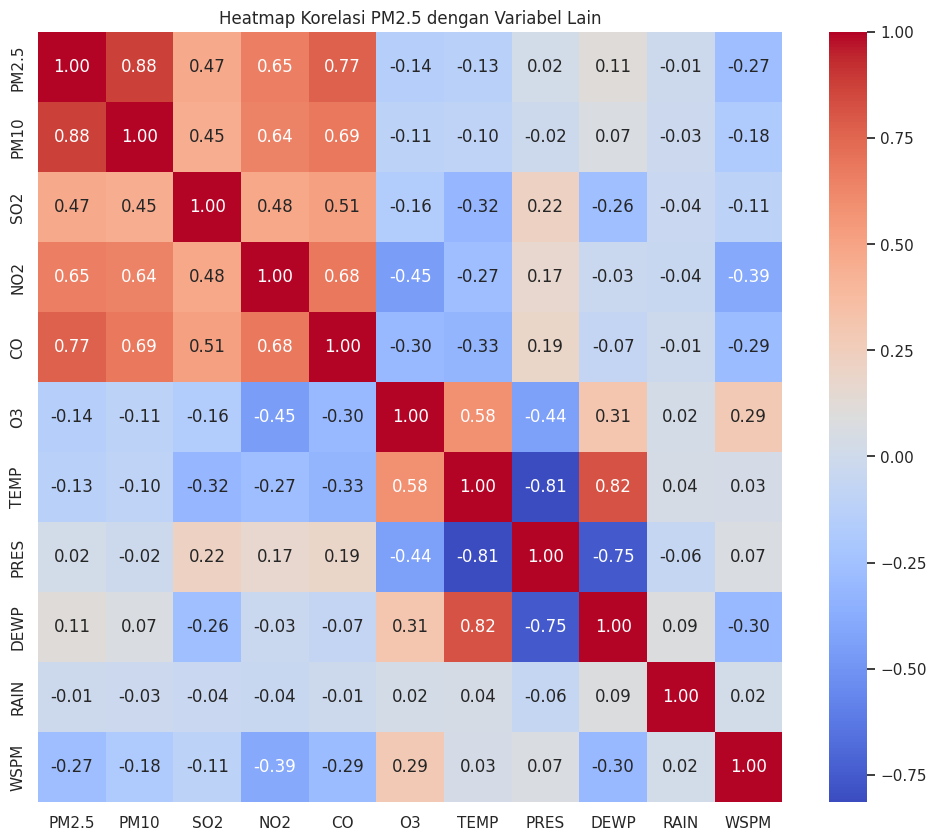

In [24]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi PM2.5 dengan Variabel Lain")
plt.show()

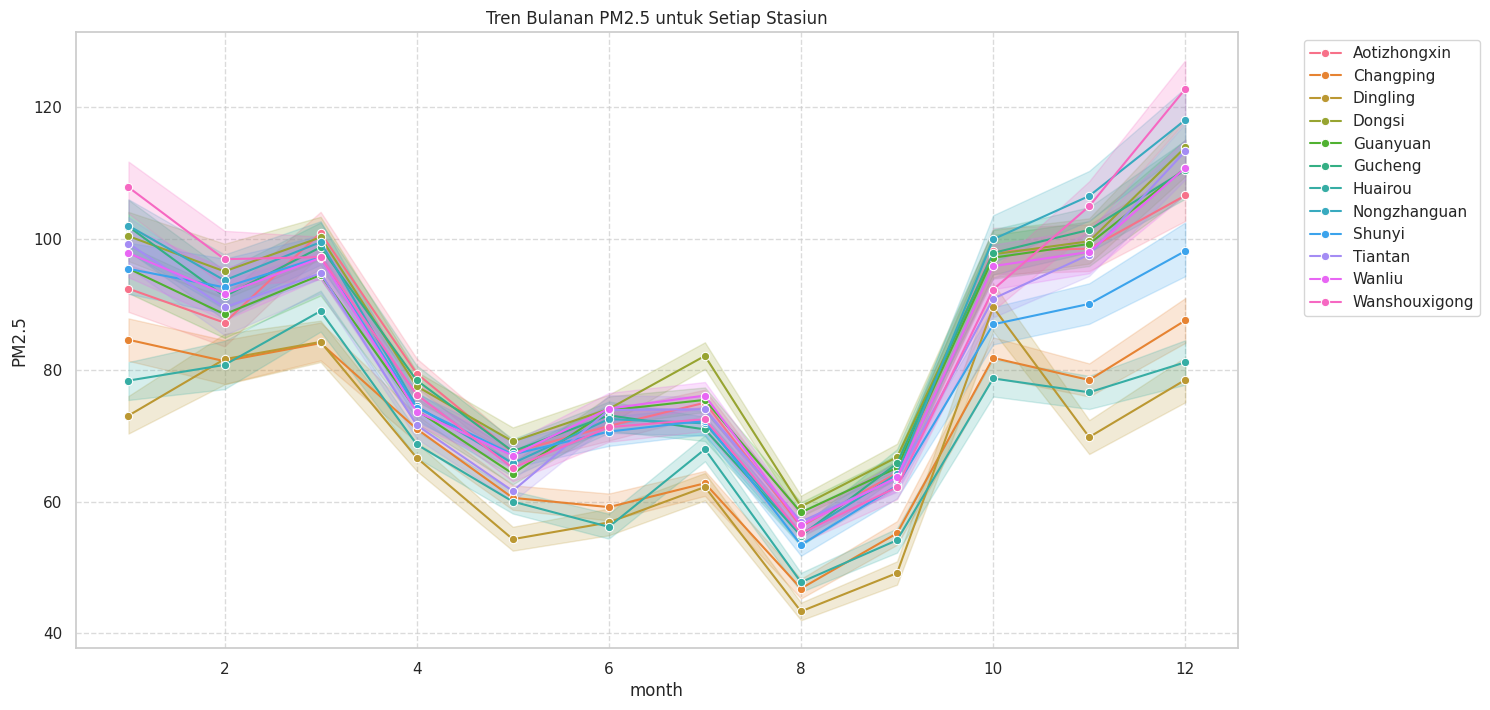

Ringkasan Statistik PM2.5 per Stasiun:


,mean,max,min,std
station,,,,
Dongsi,86.310293,737.0,3.0,86.337389
Wanshouxigong,85.356562,999.0,3.0,86.627607
Nongzhanguan,85.289471,844.0,2.0,86.984595
Gucheng,84.345203,770.0,2.0,83.228885
Wanliu,83.516054,957.0,2.0,82.177505
Aotizhongxin,83.163652,898.0,3.0,82.290700
Guanyuan,83.047023,680.0,2.0,81.307042
Tiantan,82.255892,821.0,3.0,81.130568
Shunyi,80.021067,941.0,2.0,82.094866



Korelasi PM2.5 dengan Faktor Lingkungan:
PM2.5    1.000000
TEMP    -0.130454
PRES     0.019145
DEWP     0.112820
RAIN    -0.014153
WSPM    -0.269565
Name: PM2.5, dtype: float64


In [26]:

# Analisis Tren Bulanan per Stasiun
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_clean, x='month', y='PM2.5', hue='station', marker='o')
plt.title('Tren Bulanan PM2.5 untuk Setiap Stasiun')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Ringkasan Statistik untuk Kesimpulan Akhir
final_summary = df_clean.groupby('station')['PM2.5'].agg(['mean', 'max', 'min', 'std']).sort_values(by='mean', ascending=False)
print("Ringkasan Statistik PM2.5 per Stasiun:")
display(final_summary)

# Menghitung korelasi spesifik untuk variabel lingkungan
env_corr = df_clean[['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()['PM2.5']
print("\nKorelasi PM2.5 dengan Faktor Lingkungan:")
print(env_corr)

## Conclusion

- **Kesimpulan pertanyaan 1:** Konsentrasi PM2.5 menunjukkan pola perubahan berdasarkan waktu, baik dalam skala bulanan maupun harian. Hal ini menandakan adanya pengaruh faktor musiman dan dinamika aktivitas harian terhadap kualitas udara.
- **Kesimpulan pertanyaan 2:** Rata-rata PM2.5 berbeda antar stasiun. Ada stasiun dengan tingkat polusi lebih tinggi dibanding stasiun lainnya, sehingga lokasi pengamatan menjadi faktor penting dalam evaluasi kualitas udara.
